Import Required Libraries

Standard Python libraries are imported to support data handling, visualization, machine learning model construction, and evaluation. Pandas and NumPy are used for data manipulation, Matplotlib and Seaborn for exploratory visualization, and Scikit-learn for preprocessing, training, and evaluating classification models.

In [2]:
# Sunjeda Islam (2022-1-60-194)
# ==========================================================
# Mushroom Classification Lab Task
# Models: Decision Tree and Random Forest
# Dataset: UCI Mushroom Dataset
# Platform: Google Colab
# ==========================================================

# ----------------------------------------------------------
# 1. Import Required Libraries
# ----------------------------------------------------------
# pandas and numpy are used for data handling and numerical operations
# matplotlib and seaborn are used for visualization
# scikit-learn is used for preprocessing, model building, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


Dataset Loading

The Mushroom dataset is loaded directly from the UCI Machine Learning Repository to ensure data authenticity and reproducibility. Since the dataset does not include column headers, meaningful attribute names are manually assigned. All variables in the dataset are categorical.

In [3]:
# ----------------------------------------------------------
# 2. Load the Mushroom Dataset
# ----------------------------------------------------------
# The dataset is loaded directly from the UCI repository
# All attributes in this dataset are categorical

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

columns = [
    "class","cap-shape","cap-surface","cap-color","bruises","odor",
    "gill-attachment","gill-spacing","gill-size","gill-color",
    "stalk-shape","stalk-root","stalk-surface-above-ring",
    "stalk-surface-below-ring","stalk-color-above-ring",
    "stalk-color-below-ring","veil-type","veil-color",
    "ring-number","ring-type","spore-print-color",
    "population","habitat"
]

df = pd.read_csv(url, header=None, names=columns)


Exploratory Data Analysis (EDA)

Exploratory analysis is performed to understand the dataset structure and quality. The dataset shape is examined to confirm correct loading, and the first few records are inspected to understand feature values. A class distribution plot is used to check whether edible and poisonous classes are balanced. The dataset is also checked for missing values to ensure data completeness.

Dataset Shape: (8124, 23)


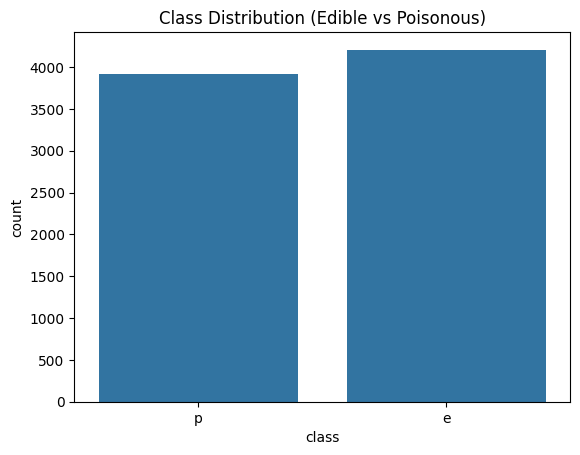

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [4]:
# ----------------------------------------------------------
# 3. Exploratory Data Analysis (EDA)
# ----------------------------------------------------------

# Display dataset dimensions (rows and columns)
print("Dataset Shape:", df.shape)

# Display the first five records of the dataset
df.head()

# ----------------------------------------------------------
# Class Distribution Visualization
# ----------------------------------------------------------
# This plot shows the distribution of edible and poisonous mushrooms

sns.countplot(x="class", data=df)
plt.title("Class Distribution (Edible vs Poisonous)")
plt.show()

# ----------------------------------------------------------
# Check for Missing Values
# ----------------------------------------------------------
# The dataset does not contain missing values

df.isnull().sum()


Data Preprocessing

Label Encoding is applied to all features because machine learning algorithms require numerical input. This encoding method is suitable as the dataset consists entirely of categorical variables and tree-based models do not assume ordinal relationships among encoded values.

In [5]:
# ----------------------------------------------------------
# 4. Data Preprocessing
# ----------------------------------------------------------
# Since all features are categorical, Label Encoding is applied
# This converts string values into numeric format required by ML models

label_encoder = LabelEncoder()

for column in df.columns:
    df[column] = label_encoder.fit_transform(df[column])

# Separate features (X) and target variable (y)
X = df.drop("class", axis=1)
y = df["class"]

Feature and Target Separation

The dataset is divided into input features (X) and the target variable (y). This separation is necessary for supervised learning, where models learn patterns from labeled data.

Train–Test Split

The data is split into 80% training and 20% testing subsets to evaluate model performance on unseen data. A fixed random state is used to ensure reproducibility of results.

In [6]:
# ----------------------------------------------------------
# Train-Test Split
# ----------------------------------------------------------
# The dataset is split into 80% training and 20% testing data
# random_state is fixed to ensure reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Decision Tree Classification

A Decision Tree classifier is trained as a baseline model. It learns decision rules directly from the data and performs well due to the highly separable nature of the Mushroom dataset.

In [7]:
# ----------------------------------------------------------
# 5. Decision Tree Classifier
# ----------------------------------------------------------
# A Decision Tree model is trained as a baseline classifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [8]:
# Make predictions on test data
dt_predictions = dt_model.predict(X_test)


In [9]:
# Calculate accuracy of Decision Tree
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


Random Forest Classification

Multiple Random Forest models are trained using different values of n_estimators (1, 50, 100, 150, 200, 250) to analyze the effect of ensemble size on accuracy. Random Forest improves robustness by combining predictions from multiple decision trees.

In [10]:
# ----------------------------------------------------------
# 6. Random Forest Classifier with Different n_estimators
# ----------------------------------------------------------
# Random Forest models are trained with different numbers of trees
# This evaluates the effect of n_estimators on classification accuracy

n_estimators_values = [1, 50, 100, 150, 200, 250]
rf_accuracies = []

for n in n_estimators_values:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, rf_predictions)
    rf_accuracies.append(accuracy)
    print(f"Random Forest Accuracy (n_estimators={n}): {accuracy}")

Random Forest Accuracy (n_estimators=1): 1.0
Random Forest Accuracy (n_estimators=50): 1.0
Random Forest Accuracy (n_estimators=100): 1.0
Random Forest Accuracy (n_estimators=150): 1.0
Random Forest Accuracy (n_estimators=200): 1.0
Random Forest Accuracy (n_estimators=250): 1.0


Accuracy Comparison

A line plot is used to visualize Random Forest accuracy against different numbers of trees. The accuracy remains close to 100% across configurations, indicating strong predictive features and low noise in the dataset.

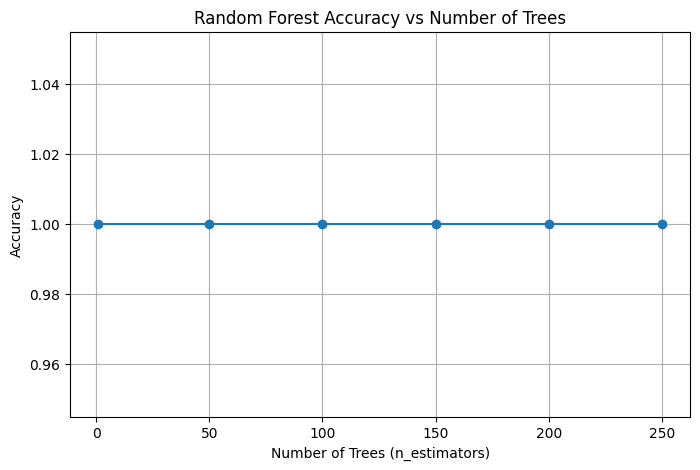

In [11]:
# ----------------------------------------------------------
# 7. Accuracy Comparison Plot
# ----------------------------------------------------------
# This plot visualizes Random Forest accuracy for different tree counts

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, rf_accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()


Model Comparison Summary

A comparison table is created to summarize and compare the accuracy of the Decision Tree and Random Forest models. This provides a clear and concise performance overview suitable for lab evaluation.

Final Observation

The Mushroom dataset is noise-free and highly separable; therefore, both Decision Tree and Random Forest models achieve near-perfect accuracy. Random Forest offers greater stability, although accuracy improvements plateau as the number of trees increases.

In [12]:
# ----------------------------------------------------------
# 8. Final Model Comparison Table
# ----------------------------------------------------------
# A summary table comparing Decision Tree and Random Forest performance

comparison_table = pd.DataFrame({
    "Model": ["Decision Tree"] + [f"Random Forest ({n})" for n in n_estimators_values],
    "Accuracy": [dt_accuracy] + rf_accuracies
})

comparison_table

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest (1),1.0
2,Random Forest (50),1.0
3,Random Forest (100),1.0
4,Random Forest (150),1.0
5,Random Forest (200),1.0
6,Random Forest (250),1.0
